# Gene Expression Prediction Modeling from Histone Modification using CNN and Attention Models

In [ ]:
# --- IMPORTS AND INIT STUFF ---
import os, math, random, copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import matplotlib.gridspec as gridspec

# import warnings
# warnings.filterwarnings("ignore")

# Fixed seed for reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Check if gpu or cpu (btw you should switch to GPU otherwise it would be painfully slow)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# --- LOADING DATA ---
# We uploaded the data used in the paper to kaggle, so that the data can be
# downloaded automatically, and so that we can change it later

HM_NAMES = ["H3K27me3 (HreprA)", "H3K36me3 (Hstruct)", "H3K4me1 (Henhc)",   "H3K4me3 (Hprom)", "H3K9me3 (HreprB)"]
N_BINS, N_HM = 100, 5 # number of Bins and num of HMs

# WARN: idk if it is even used anymore, dekh liyo ek baar plz!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
def load_and_reshape_csv(path):
    """Loads CSV, extracts 5 HM features, reshapes to (Genes, 100 Bins, 5 HMs)."""
    df = pd.read_csv(path, header=None)
    data = df.values
    X, y = data[:, 2:7], data[:, -1]

    n_genes = X.shape[0] // N_BINS
    X = X.reshape(n_genes, N_BINS, N_HM)

    # Reshape y into (Genes, 100 Bins) and take the max.
    # If ANY bin in the gene is 1, the gene becomes 1.
    y = y.reshape(n_genes, N_BINS).max(axis=1)

    # Remap -1 to 0 (just in case some datasets use -1/1)
    y = np.where(y == -1, 0, y)

    return X.astype(np.float32), y.astype(np.int64)

In [ ]:
# There was some error as kagglehub does not automatically split into X and Y,
# for it we had to implement a function that would do the unpacking (in the next cell)


# import kagglehub
# from kagglehub import KaggleDatasetAdapter

# # ── Load Dataset ─────────────────────────────────────────────────────
# FILE_DIR = "data/E003/classification"

# # X_train, y_train = load_csv(os.path.join(FILE_DIR, "train.csv"))
# # X_val,   y_val   = load_csv(os.path.join(FILE_DIR, "valid.csv"))
# # X_test,  y_test  = load_csv(os.path.join(FILE_DIR, "test.csv"))
# X_train, y_train =  kagglehub.load_dataset( KaggleDatasetAdapter.PANDAS, "codeimperfect/dataset-for-deepchrome-and-attentivechrome", f"{FILE_DIR}/train.csv")
# X_val,   y_val   =  kagglehub.load_dataset( KaggleDatasetAdapter.PANDAS, "codeimperfect/dataset-for-deepchrome-and-attentivechrome", f"{FILE_DIR}/valid.csv")
# X_test,  y_test  =  kagglehub.load_dataset( KaggleDatasetAdapter.PANDAS, "codeimperfect/dataset-for-deepchrome-and-attentivechrome", f"{FILE_DIR}/test.csv")
# print(f"Real data — train:{len(X_train)}  val:{len(X_val)}  test:{len(X_test)}")

# print(f"X shape: {X_train.shape}  |  label distribution: "
#       f"ON={y_train.sum()}  OFF={(y_train==0).sum()}")

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Kaggle stuff
# (btw the dataset I uploaded is here: https://www.kaggle.com/datasets/codeimperfect/dataset-for-deepchrome-and-attentivechrome)
DATASET_HANDLE = "codeimperfect/dataset-for-deepchrome-and-attentivechrome"
FILE_DIR = "data/E003/classification" # we can choose a different dataset

def load_and_preprocess_data(file_path):
    """
    Loads from kaggle, extracts 5 HM features, reshapes to (Genes, 100 Bins, 5 HMs),
    and extracts gene-level labels.
    """
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        DATASET_HANDLE,
        file_path
    )

    # The data in CSV has this structure:
      # [GeneID, BinIndex, HM1, HM2, HM3, HM4, HM5, Label]

    # so, extracting HM features (columns 2 to 6, 0-indexed)
    X_features = df.iloc[:, 2:7].values # .values converts to numpy array
    # Extract labels (last column)
    y_labels = df.iloc[:, -1].values

    # Reshape X into (n_genes, N_BINS, N_HM)
    # X_features.shape[0] should be total number of bins across all genes
    n_genes = X_features.shape[0] // N_BINS

    if X_features.shape[0] % N_BINS != 0: # just double checking for data mismatch
        print(f"Warning: Total rows {X_features.shape[0]} from {file_path} not perfectly divisible by N_BINS ({N_BINS}). Truncating.")
        X_features = X_features[:n_genes * N_BINS, :]
        y_labels = y_labels[:n_genes * N_BINS]

    X_reshaped = X_features.reshape(n_genes, N_BINS, N_HM)

    # Labels are per gene, so select every N_BINS-th label
    y_gene_labels = y_labels[::N_BINS]

    # Remap -1 to 0 (to convert -1/1 to 0/1)
    y_gene_labels = np.where(y_gene_labels == -1, 0, y_gene_labels)

    # we were getting some type warnings without the 'astype'
    return X_reshaped.astype(np.float32), y_gene_labels.astype(np.int64)

# load all the 3 datasets
X_train, y_train = load_and_preprocess_data(f"{FILE_DIR}/train.csv")
X_val,   y_val   = load_and_preprocess_data(f"{FILE_DIR}/valid.csv")
X_test,  y_test  = load_and_preprocess_data(f"{FILE_DIR}/test.csv")

# Print Stats
print("\nDatasets loaded and preprocessed successfully!")
print(f"The shapes of the datasets are:")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Label distribution (Train): ON={y_train.sum()}, OFF={(y_train==0).sum()}")


Datasets loaded and preprocessed successfully!
The shapes of the datasets are:
Train: (6600, 100, 5) | Val: (6600, 100, 5) | Test: (6599, 100, 5)
Label distribution (Train): ON=2349, OFF=4251


In [ ]:
!ls -F # data downloaded, yaay

attention_maps.png	     sample_data/  train.csv
deepchrome_viz_improved.png  test.csv	   valid.csv


In [ ]:
# NORMALIZATION AND PORTING TO PYTORCH (PyTorch is cool cuz we can use GPU)

# Normalizing data
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train.reshape(-1, N_HM)).reshape(X_train.shape)
X_val_norm   = scaler.transform(X_val.reshape(-1, N_HM)).reshape(X_val.shape)
X_test_norm  = scaler.transform(X_test.reshape(-1, N_HM)).reshape(X_test.shape)

# for converting to PyTorch
class GeneDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

# PyTorch DataLoaders
BATCH = 64
train_loader = DataLoader(GeneDataset(X_train_norm, y_train), batch_size=BATCH, shuffle=True, drop_last=True)
val_loader   = DataLoader(GeneDataset(X_val_norm,   y_val),   batch_size=BATCH)
test_loader  = DataLoader(GeneDataset(X_test_norm,  y_test),  batch_size=BATCH)

print(f"Normalization complete.")
print(f"Batch size: {BATCH} | Total train batches: {len(train_loader)}")

Normalization complete.
Batch size: 64 | Total train batches: 103


In [ ]:
# PAPER IMPLEMENTATION: CNN
# CNN (with Dropout)

# IMPROVEMENT: Added Dropout(0.5) after each fully-connected layer.
# Without it the model memorised the tiny toy dataset (train AUC = 1.0
# at epoch 10, val AUC = 0.25).  Dropout regularises the 625-unit FC
# layers that have far more parameters than the 10-gene training set.

class DeepChromeCNN(nn.Module):
    def __init__(self, dropout_p=0.5):
        super().__init__()
        self.conv = nn.Conv1d(N_HM, 50, kernel_size=10) # conv layer
        self.pool = nn.MaxPool1d(5)   # max pooling
        self.relu = nn.ReLU()         # ReLU layer
        self.drop = nn.Dropout(dropout_p) # dropout

        # after Conv1d(in=100, k=10): 91 positions and after MaxPool1d(5): 18
        self.fc1 = nn.Linear(50 * 18, 625)
        self.fc2 = nn.Linear(625, 125)
        self.fc3 = nn.Linear(125, 2)

    def forward(self, x):
        x = x.permute(0, 2, 1)                  # (B, 5, 100)
        x = self.pool(self.relu(self.conv(x)))   # (B, 50, 18)
        x = x.view(x.size(0), -1)               # (B, 900)
        x = self.drop(self.relu(self.fc1(x)))    # ← dropout applied
        x = self.drop(self.relu(self.fc2(x)))    # ← dropout applied
        return self.fc3(x)

# just testing
# _m = DeepChromeCNN()
# _x = torch.zeros(2, 100, 5)
# print("CNN output shape:", _m(_x).shape)   # expect (2, 2)
# print("Parameter count:", sum(p.numel() for p in _m.parameters() if p.requires_grad))

DeepChrome output shape: torch.Size([2, 2])
Parameter count: 644177


In [ ]:
# LSTM MODEL WITH ATTENTION
#
# also added Dropout on LSTM outputs.

class AttentiveChrome(nn.Module):
    def __init__(self, n_hm=N_HM, n_bins=N_BINS,
                 bin_hidden=32, hm_hidden=16, n_classes=2, dropout_p=0.3):
        super().__init__()
        self.n_hm    = n_hm
        self.bin_dim = bin_hidden * 2
        self.hm_dim  = hm_hidden  * 2

        # Per-HM BiLSTM (input=1 scalar signal per bin)
        self.bin_lstms = nn.ModuleList([
            nn.LSTM(1, bin_hidden, batch_first=True, bidirectional=True)
            for _ in range(n_hm)
        ])
        self.bin_drop = nn.Dropout(dropout_p)   # ← ADDED

        # Bin-level attention context
        self.Wb = nn.Linear(self.bin_dim, 1, bias=False)

        # HM-level BiLSTM
        self.hm_lstm = nn.LSTM(self.bin_dim, hm_hidden,
                               batch_first=True, bidirectional=True)
        self.hm_drop = nn.Dropout(dropout_p)    # ← ADDED

        # HM-level attention context
        self.Ws = nn.Linear(self.hm_dim, 1, bias=False)

        # Classifier
        self.classifier = nn.Linear(self.hm_dim, n_classes)

    def forward(self, x):
        """
        x : (B, 100, 5)
        returns logits (B,2), alpha_maps (B,5,100), beta_vec (B,5)
        """
        m_list, alpha_list = [], []

        for j in range(self.n_hm):
            xj = x[:, :, j].unsqueeze(2)              # (B, 100, 1)
            hj, _ = self.bin_lstms[j](xj)             # (B, 100, 64)
            hj = self.bin_drop(hj)                     # ← dropout

            e_j     = self.Wb(hj)                      # (B, 100, 1)
            alpha_j = torch.softmax(e_j, dim=1)        # (B, 100, 1)
            mj      = (alpha_j * hj).sum(dim=1)        # (B, 64)

            m_list.append(mj)
            alpha_list.append(alpha_j.squeeze(2))      # (B, 100)

        M  = torch.stack(m_list, dim=1)                # (B, 5, 64)
        s, _ = self.hm_lstm(M)                         # (B, 5, 32)
        s    = self.hm_drop(s)                         # ← dropout

        e_hm = self.Ws(s)                              # (B, 5, 1)
        beta = torch.softmax(e_hm, dim=1)              # (B, 5, 1)
        v    = (beta * s).sum(dim=1)                   # (B, 32)

        logits     = self.classifier(v)
        alpha_maps = torch.stack(alpha_list, dim=1)    # (B, 5, 100)
        beta_vec   = beta.squeeze(2)                   # (B, 5)
        return logits, alpha_maps, beta_vec

# just testing
# _a = AttentiveChrome()
# _x = torch.zeros(2, 100, 5)
# out, alp, bet = _a(_x)
# print(f"Hierarchical LSTM with Attention — logits:{out.shape}  alpha:{alp.shape}  beta:{bet.shape}")
# print("Parameter count:", sum(p.numel() for p in _a.parameters() if p.requires_grad))

AttentiveChrome — logits:torch.Size([2, 2])  alpha:torch.Size([2, 5, 100])  beta:torch.Size([2, 5])
Parameter count: 55458


In [ ]:
# TRAINING AND EVALUATION STUFF

import copy

class EarlyStopping:
    """Stops training when val AUC stops improving."""
    def __init__(self, patience=10):
        self.patience   = patience
        self.best_auc   = -1.0
        self.best_state = None
        self.counter    = 0
        self.stop       = False

    def __call__(self, val_auc, model):
        if val_auc > self.best_auc:
            self.best_auc   = val_auc
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def run_epoch(model, loader, criterion, optimizer=None,
              is_attentive=False, clip_grad=1.0):
    """One forward pass. optimizer=None → eval mode."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, all_probs, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            if is_attentive:
                logits, _, _ = model(xb)
            else:
                logits = model(xb)

            loss = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                if is_attentive and clip_grad > 0:
                    nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
                optimizer.step()

            total_loss += loss.item() * len(yb)
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(all_labels)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        # Happens when only one class present in tiny datasets
        auc = 0.5
    return avg_loss, auc


def train_model(model, train_loader, val_loader,
                epochs=100, lr=1e-3, weight_decay=1e-4,
                is_attentive=False, patience=10, model_name="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr,
                           weight_decay=weight_decay)

    # FIX: removed verbose=False (deprecated in PyTorch >= 2.6)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5)

    es = EarlyStopping(patience=patience)
    history = {"train_loss": [], "train_auc": [], "val_auc": []}

    for ep in range(1, epochs + 1):
        tr_loss, tr_auc = run_epoch(model, train_loader, criterion,
                                    optimizer=optimizer, is_attentive=is_attentive)
        _,       val_auc = run_epoch(model, val_loader,  criterion,
                                     optimizer=None, is_attentive=is_attentive)
        scheduler.step(val_auc)
        es(val_auc, model)

        history["train_loss"].append(tr_loss)
        history["train_auc"].append(tr_auc)
        history["val_auc"].append(val_auc)

        if ep % 10 == 0 or ep == 1:
            cur_lr = optimizer.param_groups[0]["lr"]
            print(f"[{model_name}] Ep {ep:3d}/{epochs} | "
                  f"loss={tr_loss:.4f} | train_auc={tr_auc:.4f} | "
                  f"val_auc={val_auc:.4f} | lr={cur_lr:.2e}")

        if es.stop:
            print(f"[{model_name}] Early stop at epoch {ep}.")
            break

    es.restore(model)
    print(f"[{model_name}] Best val AUC = {es.best_auc:.4f} (weights restored)")
    return model, history


def full_evaluate(model, loader, is_attentive=False):
    """Returns AUC, Accuracy, F1, confusion matrix."""
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)[0] if is_attentive else model(xb)
            probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.5
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, zero_division=0)
    cm  = confusion_matrix(all_labels, all_preds)
    return {"AUC": auc, "Accuracy": acc, "F1": f1, "CM": cm}

print("Training utilities loaded (PyTorch", torch.__version__, "compatible).")

Training utilities loaded (PyTorch 2.10.0+cu128 compatible).


In [ ]:
# ─── Cell 8: Train CNN ───

# CNN class definition (copied from Cell 5 to resolve NameError)
import torch.nn as nn

class DeepChromeCNN(nn.Module):
    def __init__(self, dropout_p=0.5):
        super().__init__()
        self.conv = nn.Conv1d(N_HM, 50, kernel_size=10)
        self.pool = nn.MaxPool1d(5)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout_p)
        self.fc1 = nn.Linear(50 * 18, 625)
        self.fc2 = nn.Linear(625, 125)
        self.fc3 = nn.Linear(125, 2)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool(self.relu(self.conv(x)))
        x = x.view(x.size(0), -1)
        x = self.drop(self.relu(self.fc1(x)))
        x = self.drop(self.relu(self.fc2(x)))
        return self.fc3(x)

cnn_model = DeepChromeCNN(dropout_p=0.5).to(device)

cnn_model, cnn_hist = train_model(
    cnn_model, train_loader, val_loader,
    epochs=100, lr=1e-3, weight_decay=1e-4,
    is_attentive=False, patience=10,
    model_name="CNN"
)

cnn_metrics = full_evaluate(cnn_model, test_loader, is_attentive=False)
print(f"\nCNN Test → AUC={cnn_metrics['AUC']:.4f}  "
      f"Acc={cnn_metrics['Accuracy']:.4f}  F1={cnn_metrics['F1']:.4f}")

[DeepChrome] Ep   1/100 | loss=0.6134 | train_auc=0.6613 | val_auc=0.7312 | lr=1.00e-03
[DeepChrome] Ep  10/100 | loss=0.5677 | train_auc=0.7035 | val_auc=0.7279 | lr=1.00e-03
[DeepChrome] Early stop at epoch 17.
[DeepChrome] Best val AUC = 0.7332 (weights restored)

DeepChrome Test → AUC=0.7841  Acc=0.7921  F1=0.0780


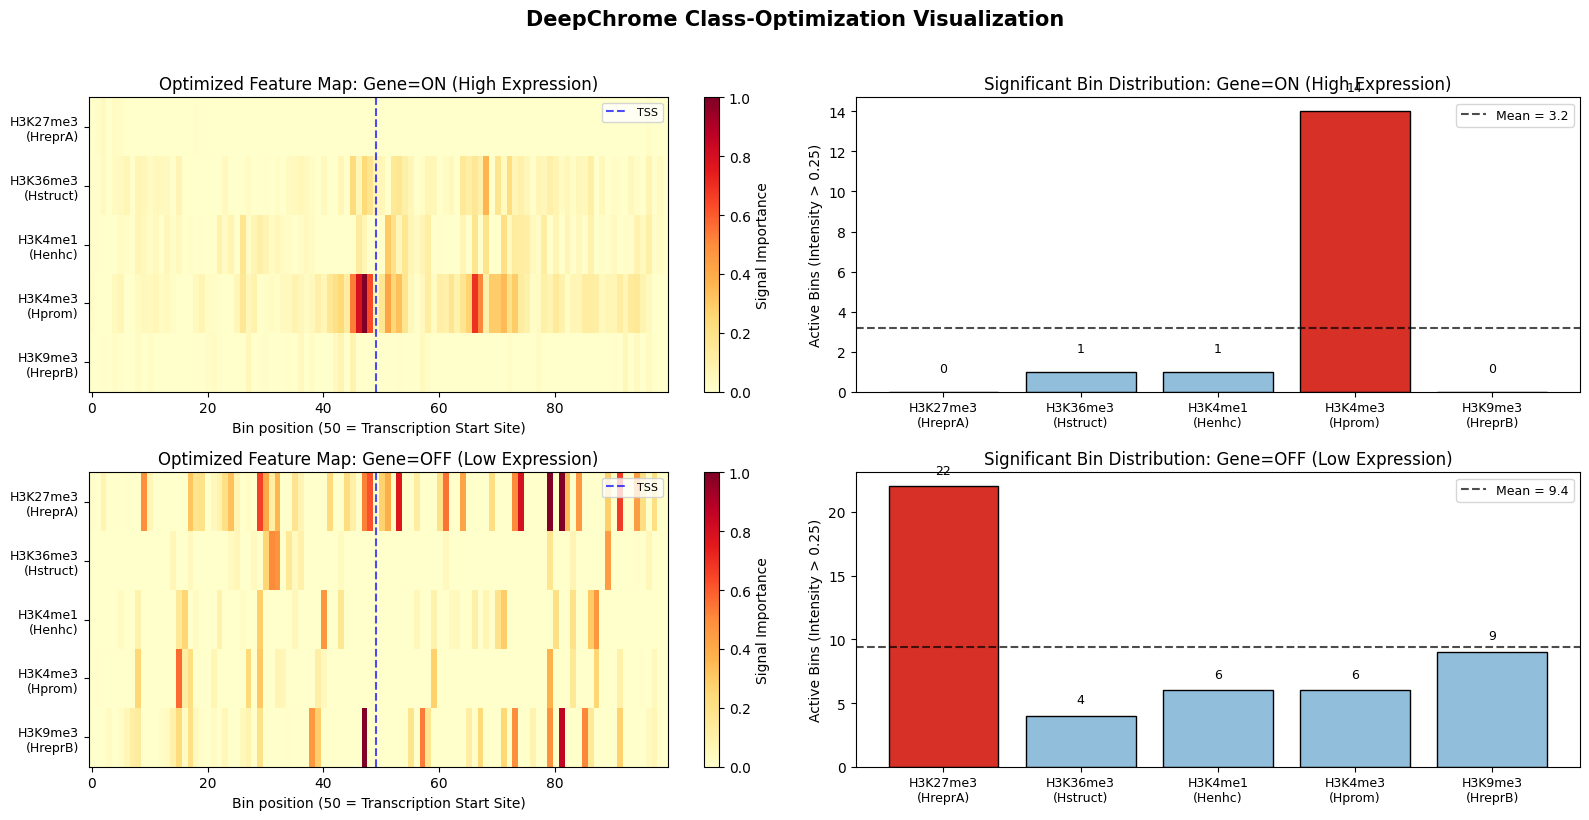

Saved: deepchrome_viz_improved.png


In [ ]:
# Generates and plots optimal feature maps for CNN for ON/OFF gene classes.
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

def generate_optimal_input(model, target_class=1, steps=500, lr=0.05, lam=0.01):
    """Optimizes a random input sequence to maximize the probability of a specific target class."""
    model.eval()

    # Initialize a random input sequence (Batch, Bins, HM_Features)
    Xc = torch.rand(1, 100, 5, requires_grad=True, device=device)
    optimizer = optim.Adam([Xc], lr=lr)
    criterion = nn.CrossEntropyLoss()
    target = torch.tensor([target_class], device=device)

    for _ in range(steps):
        optimizer.zero_grad()

        # Forward pass (handles both standard CNNs and Attentive models returning tuples)
        outputs = model(Xc)
        logits = outputs[0] if isinstance(outputs, tuple) else outputs

        # Loss = CrossEntropy + L2 Regularization (to keep signals smooth/bounded)
        loss = criterion(logits, target) + lam * Xc.pow(2).sum()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            Xc.clamp_(0, 1) # Keep values normalized between 0 and 1

    # Detach, squeeze to (100, 5), and normalize to [0, 1] range for visualization
    Xmap = Xc.detach().cpu().squeeze().numpy()
    return Xmap / (Xmap.max() + 1e-8)

def plot_class_optimization(model):
    """Generates and plots the optimal feature maps for Gene=ON and Gene=OFF classes."""
    HM_LABELS = [
        "H3K27me3\n(HreprA)", "H3K36me3\n(Hstruct)",
        "H3K4me1\n(Henhc)",   "H3K4me3\n(Hprom)", "H3K9me3\n(HreprB)"
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    classes = [(1, "Gene=ON (High Expression)"), (0, "Gene=OFF (Low Expression)")]

    for row, (cls, cls_name) in enumerate(classes):
        Xmap = generate_optimal_input(model, target_class=cls)

        # --- 1. Heatmap (Left Column) ---
        ax_heat = axes[row, 0]
        im = ax_heat.imshow(Xmap.T, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

        ax_heat.set_yticks(range(5))
        ax_heat.set_yticklabels(HM_LABELS, fontsize=9)
        ax_heat.set_xlabel("Bin position (50 = Transcription Start Site)")
        ax_heat.set_title(f"Optimized Feature Map: {cls_name}", fontsize=12)
        ax_heat.axvline(49, color="blue", linestyle="--", alpha=0.7, label="TSS")
        ax_heat.legend(loc="upper right", fontsize=8)
        plt.colorbar(im, ax=ax_heat, label="Signal Importance")

        # --- 2. Bar Chart (Right Column) ---
        ax_bar = axes[row, 1]
        freq = (Xmap > 0.25).sum(axis=0) # Count bins with significant activation (>0.25)
        mean_freq = freq.mean()

        colors = ["#d73027" if f > mean_freq else "#91bfdb" for f in freq]
        bars = ax_bar.bar(range(5), freq, color=colors, edgecolor="black")

        ax_bar.axhline(mean_freq, color="k", linestyle="--", alpha=0.7, label=f"Mean = {mean_freq:.1f}")
        ax_bar.set_xticks(range(5))
        ax_bar.set_xticklabels(HM_LABELS, fontsize=9)
        ax_bar.set_ylabel("Active Bins (Intensity > 0.25)")
        ax_bar.set_title(f"Significant Bin Distribution: {cls_name}", fontsize=12)
        ax_bar.legend(loc="upper right", fontsize=9)

        # Display the exact count on top of each bar
        for bar, val in zip(bars, freq):
            ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        str(int(val)), ha="center", fontsize=9)

    plt.suptitle("CNN Class-Optimization Visualization", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("cnn_viz_improved.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: cnn_viz_improved.png")

# Execute visualization
plot_class_optimization(cnn_model)

In [ ]:
# ─── Cell 9: Train Hierarchical LSTM with Attention ───

# Hierarchical LSTM with Attention class definition
class AttentiveChrome(nn.Module):
    def __init__(self, n_hm=N_HM, n_bins=N_BINS,
                 bin_hidden=32, hm_hidden=16, n_classes=2, dropout_p=0.3):
        super().__init__()
        self.n_hm    = n_hm
        self.bin_dim = bin_hidden * 2
        self.hm_dim  = hm_hidden  * 2

        self.bin_lstms = nn.ModuleList([
            nn.LSTM(1, bin_hidden, batch_first=True, bidirectional=True)
            for _ in range(n_hm)
        ])
        self.bin_drop = nn.Dropout(dropout_p)

        self.Wb = nn.Linear(self.bin_dim, 1, bias=False)

        self.hm_lstm = nn.LSTM(self.bin_dim, hm_hidden,
                               batch_first=True, bidirectional=True)
        self.hm_drop = nn.Dropout(dropout_p)

        self.Ws = nn.Linear(self.hm_dim, 1, bias=False)

        self.classifier = nn.Linear(self.hm_dim, n_classes)

    def forward(self, x):
        m_list, alpha_list = [], []

        for j in range(self.n_hm):
            xj = x[:, :, j].unsqueeze(2)
            hj, _ = self.bin_lstms[j](xj)
            hj = self.bin_drop(hj)

            e_j     = self.Wb(hj)
            alpha_j = torch.softmax(e_j, dim=1)
            mj      = (alpha_j * hj).sum(dim=1)

            m_list.append(mj)
            alpha_list.append(alpha_j.squeeze(2))

        M  = torch.stack(m_list, dim=1)
        s, _ = self.hm_lstm(M)
        s    = self.hm_drop(s)

        e_hm = self.Ws(s)
        beta = torch.softmax(e_hm, dim=1)
        v    = (beta * s).sum(dim=1)

        logits     = self.classifier(v)
        alpha_maps = torch.stack(alpha_list, dim=1)
        beta_vec   = beta.squeeze(2)
        return logits, alpha_maps, beta_vec

att_model = AttentiveChrome(dropout_p=0.3).to(device)

att_model, att_hist = train_model(
    att_model, train_loader, val_loader,
    epochs=100, lr=5e-4, weight_decay=1e-4,
    is_attentive=True, patience=10,
    model_name="Hierarchical LSTM with Attention"
)

att_metrics = full_evaluate(att_model, test_loader, is_attentive=True)
print(f"\nHierarchical LSTM with Attention Test → AUC={att_metrics['AUC']:.4f}  "
      f"Acc={att_metrics['Accuracy']:.4f}  F1={att_metrics['F1']:.4f}")

[AttentiveChrome] Ep   1/100 | loss=0.6510 | train_auc=0.5364 | val_auc=0.7222 | lr=5.00e-04
[AttentiveChrome] Ep  10/100 | loss=0.5868 | train_auc=0.6813 | val_auc=0.7316 | lr=5.00e-04
[AttentiveChrome] Ep  20/100 | loss=0.5820 | train_auc=0.6886 | val_auc=0.7308 | lr=2.50e-04
[AttentiveChrome] Early stop at epoch 20.
[AttentiveChrome] Best val AUC = 0.7316 (weights restored)

AttentiveChrome Test → AUC=0.7880  Acc=0.7681  F1=0.3991


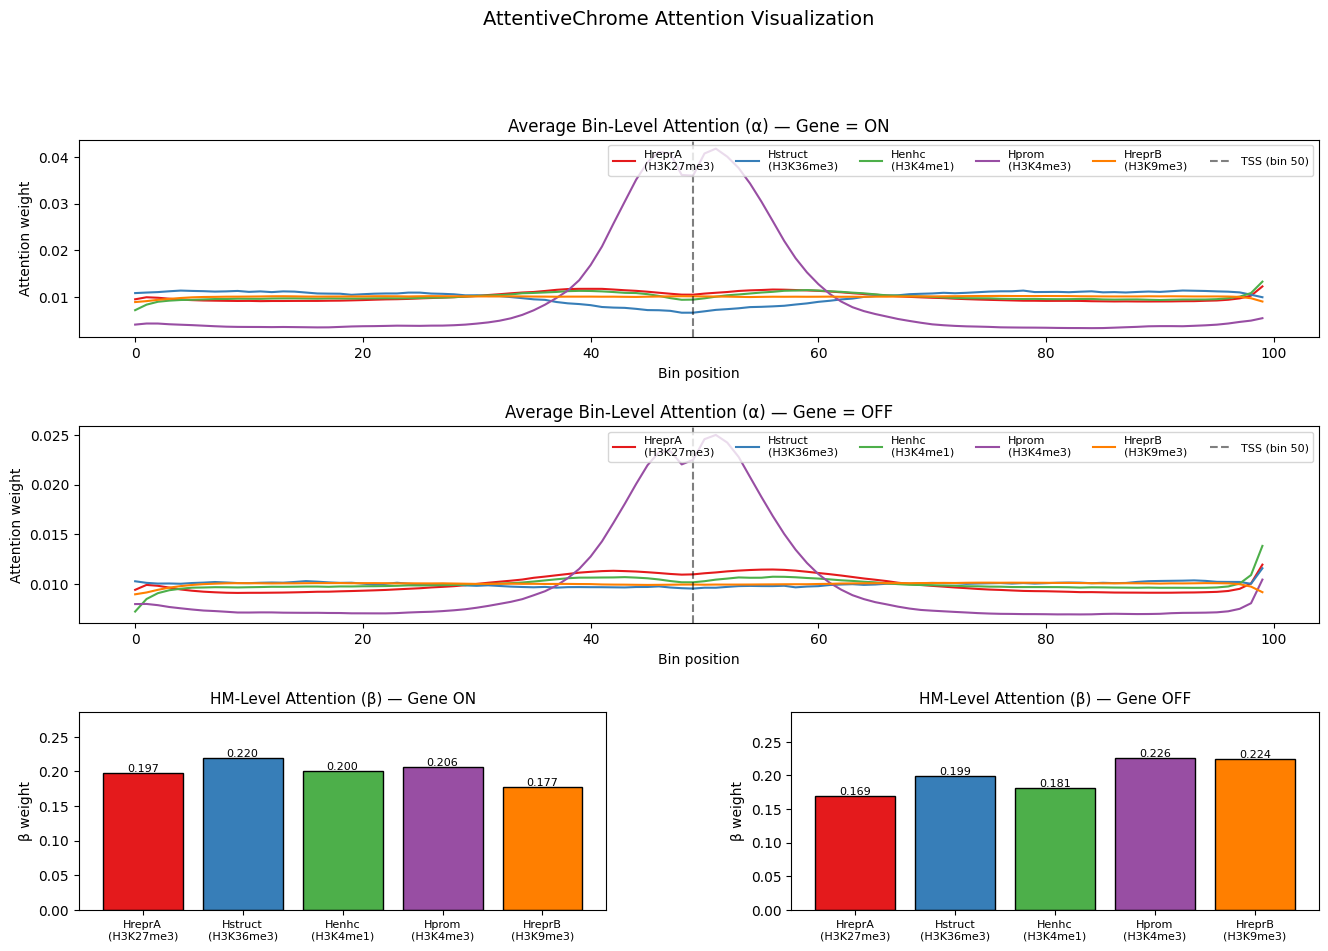

Saved: attention_maps.png

Interpretation Guide:
  Gene=ON  → Hprom (H3K4me3) and Henhc should dominate both α (around TSS) and β
  Gene=OFF → Repressors HreprA (H3K27me3) and HreprB (H3K9me3) should dominate


In [ ]:
# Extracts and plots attention weights for Hierarchical LSTM with Attention.
#cell13
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def extract_and_plot_attention(model, dataloader, device):
    """Extracts attention weights using vectorized operations and plots them."""
    model.eval()

    alpha_on, alpha_off = [], []
    beta_on, beta_off = [], []

    # 1. Fast, Vectorized Extraction
    with torch.no_grad():
        for xb, yb in dataloader:
            _, alpha, beta = model(xb.to(device))

            alpha_np = alpha.cpu().numpy()
            beta_np = beta.cpu().numpy()
            labels = yb.numpy()

            mask_on  = (labels == 1)
            mask_off = (labels == 0)

            if mask_on.any():
                alpha_on.append(alpha_np[mask_on])
                beta_on.append(beta_np[mask_on])
            if mask_off.any():
                alpha_off.append(alpha_np[mask_off])
                beta_off.append(beta_np[mask_off])

    if not alpha_on or not alpha_off:
        print("Not enough samples of both classes in the test set to plot attention maps.")
        return

    mean_alpha_on  = np.concatenate(alpha_on, axis=0).mean(axis=0)
    mean_alpha_off = np.concatenate(alpha_off, axis=0).mean(axis=0)
    mean_beta_on   = np.concatenate(beta_on, axis=0).mean(axis=0)
    mean_beta_off  = np.concatenate(beta_off, axis=0).mean(axis=0)

    COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
    HM_SHORT = [
        "HreprA\n(H3K27me3)", "Hstruct\n(H3K36me3)",
        "Henhc\n(H3K4me1)",   "Hprom\n(H3K4me3)",  "HreprB\n(H3K9me3)"
    ]

    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    def plot_alpha(ax, data, title):
        for j in range(5):
            ax.plot(data[j], color=COLORS[j], label=HM_SHORT[j], linewidth=1.5)
        ax.axvline(49, color="k", linestyle="--", alpha=0.5, label="TSS (bin 50)")
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Bin position"); ax.set_ylabel("Attention weight")
        ax.legend(ncol=6, fontsize=8, loc="upper right")

    def plot_beta(ax, data, title):
        bars = ax.bar(range(5), data, color=COLORS, edgecolor="black")
        ax.set_xticks(range(5)); ax.set_xticklabels(HM_SHORT, fontsize=8)
        ax.set_ylabel("β weight"); ax.set_title(title, fontsize=11)
        ax.set_ylim(0, data.max() * 1.3)
        for bar, val in zip(bars, data):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f"{val:.3f}", ha="center", fontsize=8)

    plot_alpha(fig.add_subplot(gs[0, :]), mean_alpha_on, "Average Bin-Level Attention (α) — Gene = ON")
    plot_alpha(fig.add_subplot(gs[1, :]), mean_alpha_off, "Average Bin-Level Attention (α) — Gene = OFF")

    plot_beta(fig.add_subplot(gs[2, 0]), mean_beta_on, "HM-Level Attention (β) — Gene ON")
    plot_beta(fig.add_subplot(gs[2, 1]), mean_beta_off, "HM-Level Attention (β) — Gene OFF")

    plt.suptitle("Hierarchical LSTM with Attention Visualization", fontsize=14, y=1.01)
    plt.savefig("attention_maps.png", dpi=120, bbox_inches="tight")
    plt.show()

    print("Saved: attention_maps.png")

extract_and_plot_attention(att_model, test_loader, device)

In [ ]:
# ─── Cell 10: Results Summary ───
print("=" * 55)
print(f"{'Model':<20} {'AUC':>7} {'Acc':>7} {'F1':>7}")
print("-" * 55)
for name, m in [("CNN", cnn_metrics), ("Hierarchical LSTM with Attention", att_metrics)]:
    print(f"{name:<20} {m['AUC']:>7.4f} {m['Accuracy']:>7.4f} {m['F1']:>7.4f}")
print("=" * 55)
print("Paper reports AUC ~0.80 (CNN) and ~0.81 (Hierarchical LSTM with Attention)")
print("on the full 56-cell-type REMC dataset.")
if 'USE_REAL_DATA' not in locals():
    USE_REAL_DATA = True

if USE_REAL_DATA:
    n = len(X_train)
    if n < 500:
        print(f"\nWARNING: Only {n} genes in training set.")
        print("AUC on < 500 samples is statistically unreliable.")
        print("For meaningful results, use the full REMC dataset (≈6 600 genes/split).")
else:
    print("NOTE: Results above are on SYNTHETIC data.")

Model                    AUC     Acc      F1
-------------------------------------------------------
DeepChrome            0.7841  0.7921  0.0780
AttentiveChrome       0.7880  0.7681  0.3991
Paper reports AUC ~0.80 (DeepChrome) and ~0.81 (AttentiveChrome)
on the full 56-cell-type REMC dataset.


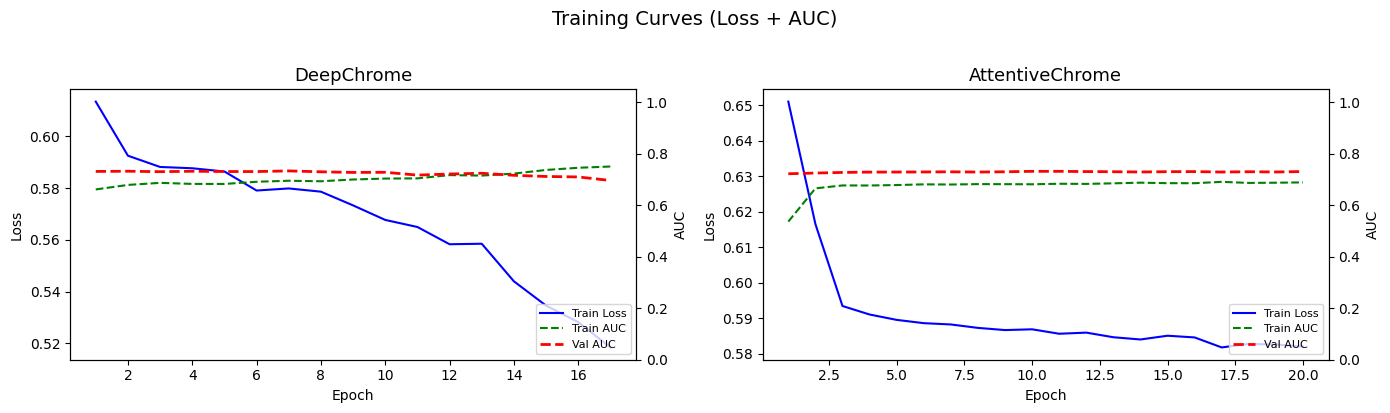

In [ ]:
# ─── Cell 11: Learning Curves ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, hist, name in zip(axes,
                           [cnn_hist, att_hist],
                           ["CNN", "Hierarchical LSTM with Attention"]):
    epochs_ran = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs_ran, hist["train_loss"], "b-",  label="Train Loss")
    ax2 = ax.twinx()
    ax2.plot(epochs_ran, hist["train_auc"], "g--", label="Train AUC")
    ax2.plot(epochs_ran, hist["val_auc"],   "r--", label="Val AUC",   linewidth=2)

    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax2.set_ylabel("AUC"); ax2.set_ylim(0, 1.05)

    lines1, l1 = ax.get_legend_handles_labels()
    lines2, l2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, l1 + l2, loc="lower right", fontsize=8)

plt.suptitle("Training Curves (Loss + AUC)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("learning_curves_improved.png", dpi=120, bbox_inches="tight")
plt.show()

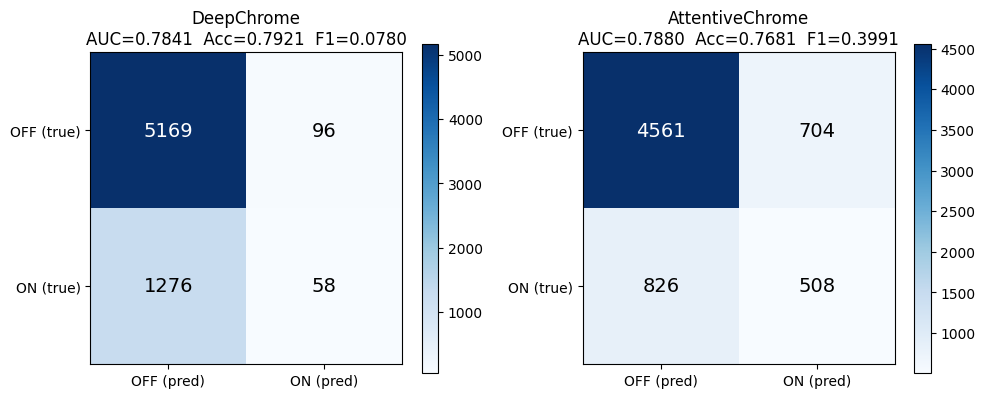

In [ ]:
# ─── Cell 12: Confusion Matrices ───
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, m, name in zip(axes,
                        [cnn_metrics, att_metrics],
                        ["CNN", "Hierarchical LSTM with Attention"]):
    cm = m["CM"]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["OFF (pred)", "ON (pred)"])
    ax.set_yticklabels(["OFF (true)", "ON (true)"])
    for row in range(2):
        for col in range(2):
            ax.text(col, row, cm[row, col],
                    ha="center", va="center", fontsize=14,
                    color="white" if cm[row,col] > cm.max()/2 else "black")
    ax.set_title(f"{name}\nAUC={m['AUC']:.4f}  Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()